# Project 2: Exploratory Data Analysis (EDA) Report
---
## Assigned Topic:
__[World Development Statistics]__

## Selected Problem Statement: 
__[Human Capital Strategy & Philanthropy]__

## 1. Introduction & Objectives
*(Guidelines: Introduce your topic and give a brief high-level overview of the industry or topic you are exploring so a non-technical audience understands the context.)*

### 1.1 Context & Background

### 1.2 Core Analytical Objectives
*(List the key targeted questions that will guide your analysis to solve the chosen problem statement. Use bullet points.)*
* ...
* ...

---

## 2. Environment Setup & Data Collection
*(Rubric Checkpoint: Ensure all modules are imported cleanly with appropriate standard aliases. Data files must be loaded using relative paths for replicability.)*

In [1]:
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import missingno as msno

In [2]:
gni=pd.read_csv('./data/gni_per_cap_atlas_method_con2021.csv')
life_exp=pd.read_csv('./data/life_expectancy.csv')
population=pd.read_csv('./data/population.csv')

---
## 3. Data Handling


In [3]:
# Initial assessment: Check shapes, null values, and summary data types
gni_long=pd.melt(frame=gni,id_vars='country',var_name='year',value_name='gni')
life_exp_long=pd.melt(frame=life_exp,id_vars='country',var_name='year',value_name='life_exp')
population_long=pd.melt(frame=population,id_vars='country',var_name='year',value_name='population')


In [4]:
print(gni_long.shape)
print(life_exp_long.shape)
print(population_long.shape)

(47941, 3)
(58695, 3)
(59297, 3)


In [5]:
print(gni_long.isna().sum())
print(life_exp_long.isna().sum())
print(population_long.isna().sum())

country      0
year         0
gni        229
dtype: int64
country        0
year           0
life_exp    2079
dtype: int64
country         0
year            0
population    100
dtype: int64


In [6]:
print(gni_long.dtypes)
print(life_exp_long.dtypes)
print(population_long.dtypes)

country       str
year          str
gni        object
dtype: object
country         str
year            str
life_exp    float64
dtype: object
country       str
year          str
population    str
dtype: object


In [7]:
gni_countries = set( gni_long['country'] )
life_countries = set( life_exp_long['country'] )
pop_countries = set( population_long['country'] )

missing_in_gni_but_in_pop = pop_countries - gni_countries
missing_in_life_but_in_pop = pop_countries - life_countries

print("In Population but missing in GNI:", missing_in_gni_but_in_pop)
print("In Population but missing in Life:", missing_in_life_but_in_pop)

In Population but missing in GNI: {'North Korea', 'Taiwan', 'Holy See', 'Andorra', 'Monaco', 'San Marino'}
In Population but missing in Life: {'Holy See', 'Liechtenstein'}


In [8]:
# Data cleaning operations (handling data types, text styling, missing values, etc.)



**converting the years to integres**

In [9]:
population_long['year']=population_long['year'].astype(int)
gni_long['year']=gni_long['year'].astype(int)
life_exp_long['year']=life_exp_long['year'].astype(int)

**Creating functions to covert the gni and populations into numbers**

In [10]:
def convert_gni_num(x):
    
    value= str(x['gni'])
    
    if 'M' in value:
        y=value.strip('M')
        return float(y)*1000000
    elif 'k' in value:
        y=value.strip('k')
        return float(y)*1000
    else:
        return float(value)

def convert_pop_num(x):
    
    value= str(x['population'])
    
    if 'B' in value:
        y=value.strip('B')
        return float(y)*1000000000
    elif 'M' in value:
        y=value.strip('M')
        return float(y)*1000000
    elif 'k' in value:
        y=value.strip('k')
        return float(y)*1000
    else:
        return float(value)

In [11]:
population_long['population']=population_long.apply(convert_pop_num,axis=1)
gni_long['gni']=gni_long.apply(convert_gni_num,axis=1)

**Handiling tables from any Nan values**

In [12]:
population_long[(population_long['population'].isna())].sort_values('year').head()

,country,year,population
39671,Holy See,2001,NaN
39868,Holy See,2002,NaN
40065,Holy See,2003,NaN
40262,Holy See,2004,NaN
40459,Holy See,2005,NaN


**Noticing that population null values are all missing values from 2001 --> 2100 from Holy See**

In [13]:
life_exp_long[(life_exp_long['life_exp'].isna())].sort_values('year')
exluded_life_countries=['Andorra','Dominica','St. Kitts and Nevis','Monaco','Marshall Islands','Nauru','Palau','San Marino','Tuvalu']

**Noticing that there are (9) countries are repeated and have null life expextance values,\
except for years from 1950 unti 2019**

**Double checking there are no missing values athor from the exluded countries:**

In [14]:
life_exp_long[(~life_exp_long['country'].isin(exluded_life_countries)) & (life_exp_long['life_exp'].isna())]

,country,year,life_exp


In [15]:
gni_long[(gni_long['gni'].isna())].sort_values('year').head()

,country,year,gni
100,Liechtenstein,1800,NaN
291,Liechtenstein,1801,NaN
482,Liechtenstein,1802,NaN
673,Liechtenstein,1803,NaN
864,Liechtenstein,1804,NaN


**Noticing that Liechtenstein always had nulll values in the GNI**

- So, I conclude that it is safe to drop the null values in population, life expectence and gni tables. 

In [16]:
# cleaned_population=population_long.dropna()
# cleaned_gni=gni_long.dropna()
# cleaned_life_exp=life_exp_long.dropna()

# cleaned_pop_life=pd.merge(left=cleaned_population, 
#                   right=cleaned_life_exp,
#                   how='left',
#                   on=(['country','year']))
# cleaned_pop_life_gni=pd.merge(left=cleaned_pop_life,
#                       right=cleaned_gni,
#                       how='left',
#                       on=(['country','year']))

In [17]:
pop_life=pd.merge(left=population_long, 
                  right=life_exp_long,
                  how='left',
                  on=(['country','year']))
pop_life_gni=pd.merge(left=pop_life,
                      right=gni_long,
                      how='left',
                      on=(['country','year']))

In [18]:
pop_life_gni.isna().sum()

country           0
year              0
population      100
life_exp       2681
gni           11585
dtype: int64

**Dropping null values**

In [19]:
cleaned_pop_life_gni=pop_life_gni.dropna(subset=['gni', 'life_exp', 'population'])

*Perecentage of kepts data*

In [20]:
print(f"Original data set size: {len(pop_life_gni)}")
print(f"After Drop data set size: {len(cleaned_pop_life_gni)}")
print(f"Percentage of data retained: {len(cleaned_pop_life_gni)/len(pop_life_gni)*100:.1f}%")

Original data set size: 59297
After Drop data set size: 46604
Percentage of data retained: 78.6%


---
## 4. Exploratory Data Analysis (EDA)
*(Rubric Checkpoint: Demonstrate mastery of basic descriptive statistics, sorting records, and applying Boolean masking techniques to isolate specific baseline metrics.)*

### 4.1. ----

**Summarizing the data**

In [21]:

summary=pd.DataFrame()
summary['year_start'] = cleaned_pop_life_gni.groupby('country')['year'].first()
summary['year_end'] = cleaned_pop_life_gni.groupby('country')['year'].last()
summary['population_start'] = cleaned_pop_life_gni.groupby('country')['population'].first()
summary['population_end'] = cleaned_pop_life_gni.groupby('country')['population'].last()
summary['life_exp_start'] = cleaned_pop_life_gni.groupby('country')['life_exp'].first()
summary['life_exp_end'] = cleaned_pop_life_gni.groupby('country')['life_exp'].last()
summary['gni_start'] = cleaned_pop_life_gni.groupby('country')['gni'].first()
summary['gni_end'] = cleaned_pop_life_gni.groupby('country')['gni'].last()
summary=summary.reset_index()
summary.head()

,country,year_start,year_end,population_start,population_end,life_exp_start,life_exp_end,gni_start,gni_end
0,Afghanistan,1800,2050,3280000.0,74100000.0,28.2,70.0,207.0,907.0
1,Albania,1800,2050,400000.0,2460000.0,35.4,82.8,207.0,11600.0
2,Algeria,1800,2050,2500000.0,60000000.0,28.8,81.2,446.0,5370.0
3,Angola,1800,2050,1570000.0,72300000.0,27.0,73.1,517.0,3340.0
4,Antigua and Barbuda,1800,2050,37000.0,99000.0,33.5,80.2,650.0,26900.0


**Checking data**

In [22]:
summary[(summary['year_start']<=1960) & (summary['year_end']<=2019)]

,country,year_start,year_end,population_start,population_end,life_exp_start,life_exp_end,gni_start,gni_end
47,Dominica,1950,2019,50200.0,71400.0,49.3,72.3,1060.0,8410.0
105,Marshall Islands,1950,2019,13100.0,44700.0,52.1,65.5,1790.0,5150.0
117,Nauru,1950,2019,3350.0,12100.0,58.5,63.4,5700.0,16900.0
128,Palau,1950,2019,7430.0,17900.0,49.0,67.5,9400.0,17000.0
158,St. Kitts and Nevis,1950,2019,47300.0,47700.0,60.8,72.1,2070.0,21600.0
176,Tuvalu,1950,2019,4730.0,11000.0,47.0,67.9,1870.0,5730.0


**6 countires has missing values on 2020.\
So, I will be calculate the last 3 years average and added to year 2020**

In [23]:
edge_countries=['Dominica','St. Kitts and Nevis','Marshall Islands','Nauru','Palau','Tuvalu']

In [24]:
edge_data = cleaned_pop_life_gni[
    (cleaned_pop_life_gni['country'].isin(edge_countries)) & 
    (cleaned_pop_life_gni['year'].isin([2017, 2018, 2019]))]

average_edge_data=edge_data.groupby('country')[['population','life_exp','gni']].mean()
average_edge_data

last_year_edge_data=cleaned_pop_life_gni[
    (cleaned_pop_life_gni['country'].isin(edge_countries)) & 
    (cleaned_pop_life_gni['year']==2019)].set_index('country')[['gni', 'life_exp', 'population']]


new_edge_data=(last_year_edge_data+(last_year_edge_data-average_edge_data)).reset_index()
new_edge_data['year']=2020

cleaned_pop_life_gni = pd.concat([cleaned_pop_life_gni, new_edge_data], ignore_index=True)
cleaned_pop_life_gni = cleaned_pop_life_gni.drop_duplicates(subset=['country', 'year'], keep='first')

In [25]:
updated_cleaned_pop_life_gni=cleaned_pop_life_gni[(cleaned_pop_life_gni['year']>=1960) & (cleaned_pop_life_gni['year']<=2020)]
updated_summary=pd.DataFrame()
updated_summary['year_start'] =updated_cleaned_pop_life_gni.groupby('country')['year'].first()
updated_summary['year_end'] =updated_cleaned_pop_life_gni.groupby('country')['year'].last()
updated_summary['population_start'] = updated_cleaned_pop_life_gni.groupby('country')['population'].first()
updated_summary['population_end'] = updated_cleaned_pop_life_gni.groupby('country')['population'].last()
updated_summary['life_exp_start'] = updated_cleaned_pop_life_gni.groupby('country')['life_exp'].first()
updated_summary['life_exp_end'] = updated_cleaned_pop_life_gni.groupby('country')['life_exp'].last()
updated_summary['gni_start'] = updated_cleaned_pop_life_gni.groupby('country')['gni'].first()
updated_summary['gni_end'] = updated_cleaned_pop_life_gni.groupby('country')['gni'].last()
updated_summary=updated_summary.reset_index()
updated_summary.sort_values('gni_end',ascending=False).head()

,country,year_start,year_end,population_start,population_end,life_exp_start,life_exp_end,gni_start,gni_end
164,Switzerland,1960,2020,5330000.0,8640000.0,71.8,83.2,48000.0,82600.0
98,Luxembourg,1960,2020,314000.0,630000.0,68.9,82.0,14200.0,80900.0
125,Norway,1960,2020,3580000.0,5380000.0,73.4,83.2,14000.0,78300.0
80,Ireland,1960,2020,2810000.0,4950000.0,70.1,81.1,6510.0,65600.0
181,United States,1960,2020,176000000.0,336000000.0,70.1,77.0,22300.0,64500.0


In [28]:
avg_life=life_exp_long[(life_exp_long['year']>=1960) & (life_exp_long['year']<=2020)].groupby('year')['life_exp'].mean()
avg_population=population_long[(population_long['year']>=1960) & (population_long['year']<=2020)].groupby('year')['population'].mean()
avg_gni=gni_long[(gni_long['year']>=1960) & (gni_long['year']<=2020)].groupby('year')['gni'].mean()

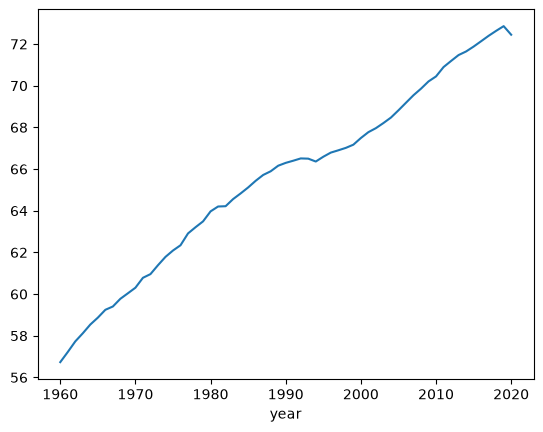

In [29]:
avg_life.plot();

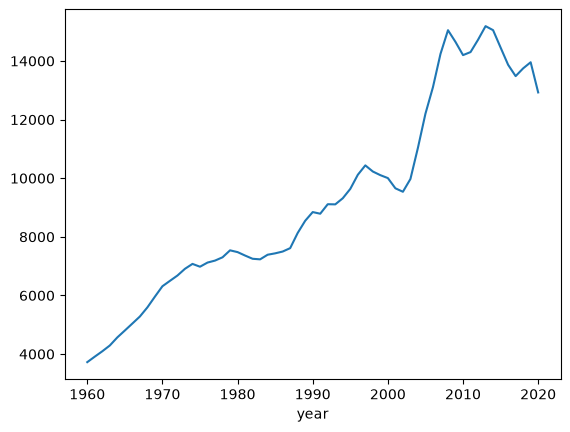

In [30]:
avg_gni.plot();

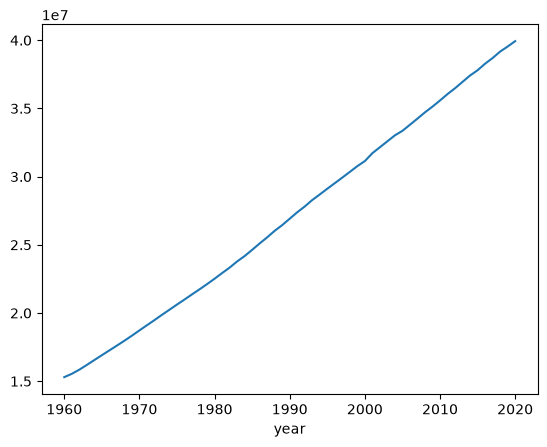

In [31]:
avg_population.plot();

### 4.2. ----

In [32]:
updated_summary['pop_growth']=round(((updated_summary['population_end']-updated_summary['population_start'])/updated_summary['population_start']),2)
updated_summary['life_exp_gain']=round((updated_summary['life_exp_end']-updated_summary['life_exp_start']),2)
updated_summary['gni_growth']=round(((updated_summary['gni_end']-updated_summary['gni_start'])/updated_summary['gni_start']),2)
updated_summary.head()

,country,year_start,year_end,population_start,population_end,life_exp_start,life_exp_end,gni_start,gni_end,pop_growth,life_exp_gain,gni_growth
0,Afghanistan,1960,2020,8620000.0,39000000.0,45.0,63.4,469.0,500.0,3.52,18.4,0.07
1,Albania,1960,2020,1710000.0,2870000.0,62.5,77.9,736.0,5210.0,0.68,15.4,6.08
2,Algeria,1960,2020,11400000.0,43500000.0,52.4,76.2,3670.0,3570.0,2.82,23.8,-0.03
3,Angola,1960,2020,5360000.0,33400000.0,46.3,65.2,1720.0,2140.0,5.23,18.9,0.24
4,Antigua and Barbuda,1960,2020,55300.0,92700.0,63.8,76.3,2790.0,13800.0,0.68,12.5,3.95


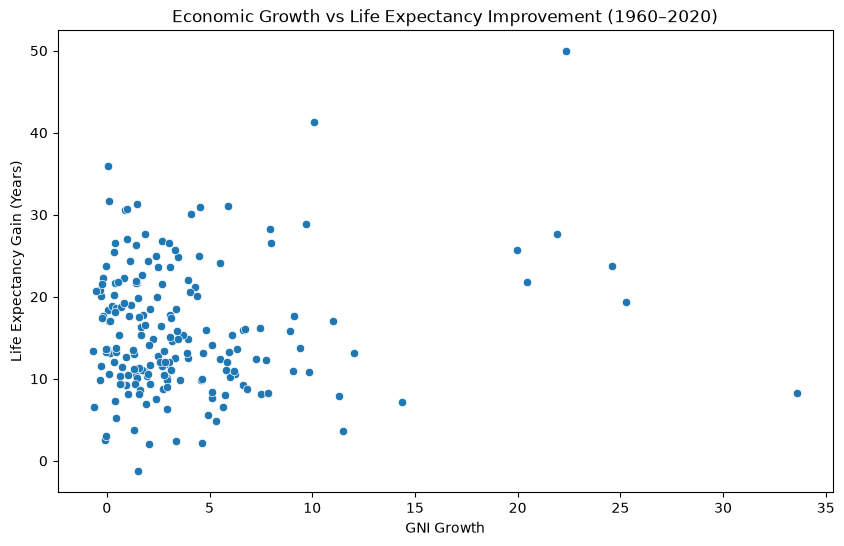

In [33]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=updated_summary,
    x="gni_growth",
    y="life_exp_gain"
)

plt.title("Economic Growth vs Life Expectancy Improvement (1960–2020)")
plt.xlabel("GNI Growth")
plt.ylabel("Life Expectancy Gain (Years)")

plt.show()

<Axes: xlabel='gni_growth', ylabel='life_exp_gain'>

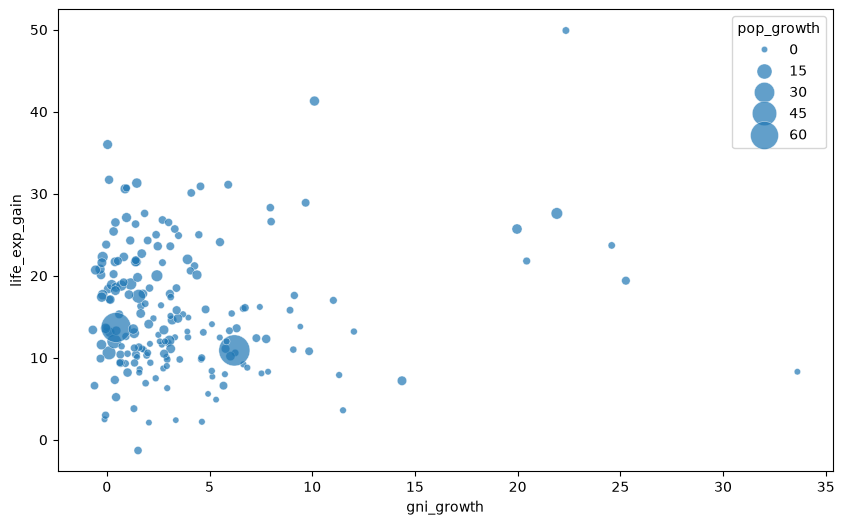

In [34]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=updated_summary,
    x="gni_growth",
    y="life_exp_gain",
    size="pop_growth",
    sizes=(20,500),
    alpha=0.7
)

In [35]:
updated_summary.sort_values(
    "gni_growth",
    ascending=False
).head(10)

,country,year_start,year_end,population_start,population_end,life_exp_start,life_exp_end,gni_start,gni_end,pop_growth,life_exp_gain,gni_growth
138,Romania,1960,2020,18500000.0,1.940000e+07,65.8,74.1,364.0,12600.0,0.05,8.3,33.62
148,Singapore,1960,2020,1600000.0,5.910000e+06,65.5,84.9,2090.0,54900.0,2.69,19.4,25.27
154,South Korea,1960,2020,25800000.0,5.180000e+07,59.1,82.8,1290.0,33000.0,1.01,23.7,24.58
34,China,1960,2020,654000000.0,1.420000e+09,27.8,77.7,454.0,10600.0,1.17,49.9,22.35
126,Oman,1960,2020,537000.0,4.540000e+06,45.1,72.7,611.0,14000.0,7.45,27.6,21.91
9,Azerbaijan,1960,2020,4130000.0,1.030000e+07,48.6,70.4,209.0,4480.0,1.49,21.8,20.44
52,Equatorial Guinea,1960,2020,267000.0,1.600000e+06,40.4,66.1,277.0,5810.0,4.99,25.7,19.97
21,Botswana,1960,2020,513000.0,2.550000e+06,54.4,61.6,432.0,6640.0,3.97,7.2,14.37
104,Malta,1960,2020,338000.0,5.150000e+05,69.1,82.3,1950.0,25400.0,0.52,13.2,12.03
112,Montenegro,1960,2020,473000.0,6.290000e+05,70.8,74.4,632.0,7900.0,0.33,3.6,11.50


In [36]:
updated_summary.sort_values(
    "life_exp_gain",ascending=False
).head(10)

,country,year_start,year_end,population_start,population_end,life_exp_start,life_exp_end,gni_start,gni_end,pop_growth,life_exp_gain,gni_growth
34,China,1960,2020,654000000.0,1.420000e+09,27.8,77.7,454.0,10600.0,1.17,49.9,22.35
102,Maldives,1960,2020,91700.0,5.140000e+05,37.8,79.1,584.0,6490.0,4.61,41.3,10.11
28,Cameroon,1960,2020,5120000.0,2.650000e+07,27.5,63.5,1460.0,1520.0,4.18,36.0,0.04
78,Iran,1960,2020,21400000.0,8.730000e+07,44.5,76.2,2660.0,2960.0,3.08,31.7,0.11
187,Yemen,1960,2020,5540000.0,3.230000e+07,36.5,67.8,355.0,872.0,4.83,31.3,1.46
18,Bhutan,1960,2020,221000.0,7.730000e+05,42.2,73.3,411.0,2840.0,2.50,31.1,5.91
12,Bangladesh,1960,2020,50400000.0,1.670000e+08,43.8,74.7,365.0,2030.0,2.31,30.9,4.56
115,Myanmar,1960,2020,21700000.0,5.340000e+07,38.7,69.4,688.0,1350.0,1.46,30.7,0.96
56,Ethiopia,1960,2020,21700000.0,1.170000e+08,38.4,69.0,471.0,890.0,4.39,30.6,0.89
133,Peru,1960,2020,10200000.0,3.330000e+07,47.3,77.4,1180.0,6030.0,2.26,30.1,4.11


In [37]:
updated_summary.sort_values(
    "pop_growth",
    ascending=False
).head(10)

,country,year_start,year_end,population_start,population_end,life_exp_start,life_exp_end,gni_start,gni_end,pop_growth,life_exp_gain,gni_growth
137,Qatar,1960,2020,36400.0,2760000.0,65.3,76.2,7770.0,56000.0,74.82,10.9,6.21
179,United Arab Emirates,1960,2020,133000.0,9290000.0,60.3,74.0,27200.0,39400.0,68.85,13.7,0.45
89,Kuwait,1960,2020,305000.0,4360000.0,69.2,81.2,24300.0,33000.0,13.30,12.0,0.36
85,Jordan,1960,2020,848000.0,10900000.0,59.4,76.9,1690.0,4310.0,11.85,17.5,1.55
46,Djibouti,1960,2020,85900.0,1090000.0,56.2,66.8,2970.0,3310.0,11.69,10.6,0.11
11,Bahrain,1960,2020,161000.0,1480000.0,57.3,76.3,9210.0,19900.0,8.19,19.0,1.16
143,Saudi Arabia,1960,2020,4170000.0,36000000.0,54.3,74.3,6370.0,21900.0,7.63,20.0,2.44
126,Oman,1960,2020,537000.0,4540000.0,45.1,72.7,611.0,14000.0,7.45,27.6,21.91
40,Cote d'Ivoire,1960,2020,3710000.0,26800000.0,45.6,64.4,1340.0,2280.0,6.22,18.8,0.70
122,Niger,1960,2020,3500000.0,24300000.0,40.3,62.6,689.0,550.0,5.94,22.3,-0.20


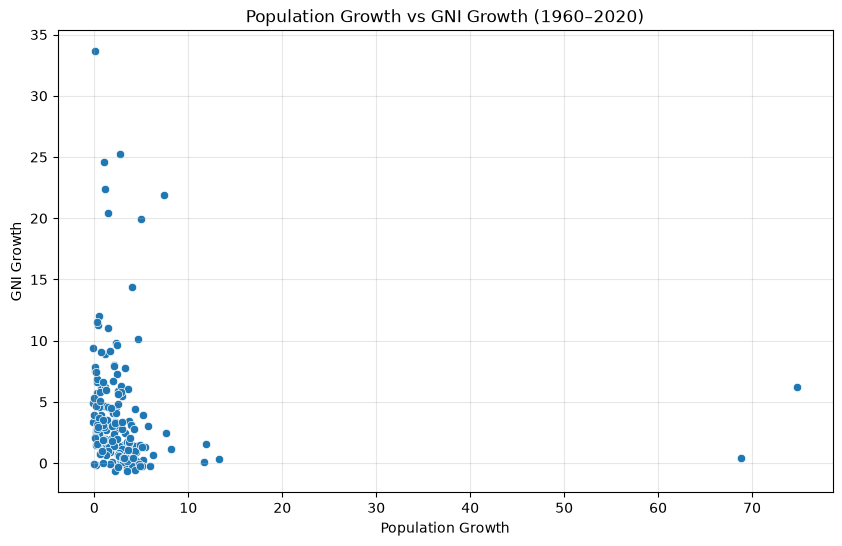

In [38]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=updated_summary,
    x='pop_growth',
    y='gni_growth'
)

plt.title("Population Growth vs GNI Growth (1960–2020)")
plt.xlabel("Population Growth")
plt.ylabel("GNI Growth")

plt.grid(alpha=0.3)
plt.show()

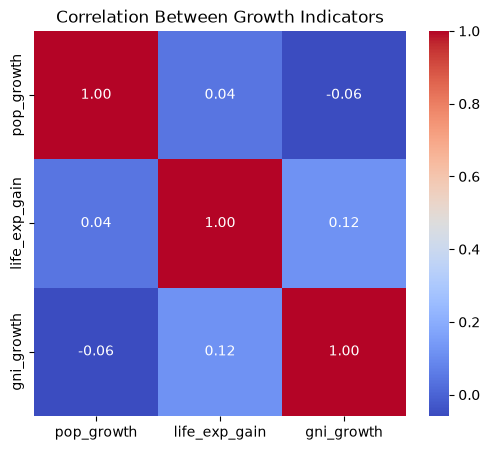

In [39]:
corr = updated_summary[
    [
        "pop_growth",
        "life_exp_gain",
        "gni_growth"
    ]
].corr()
plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Growth Indicators")

plt.show()

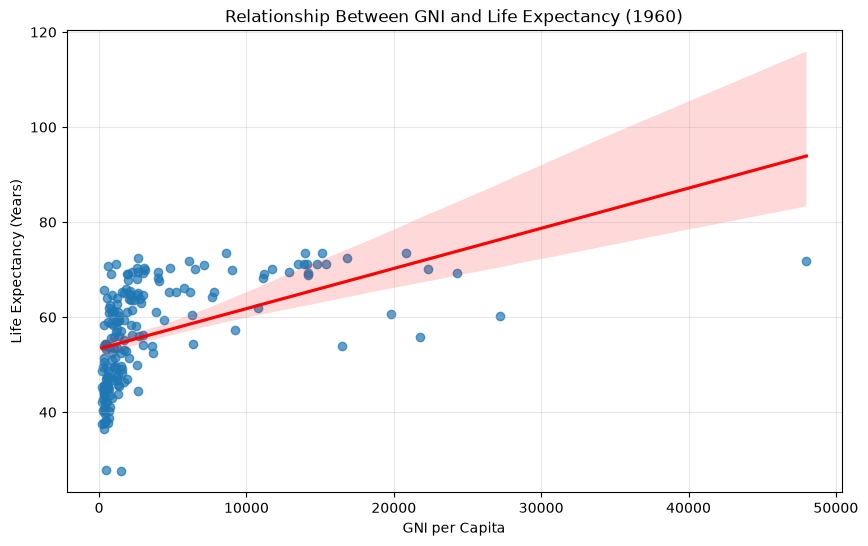

In [40]:
df_1960 = cleaned_pop_life_gni[cleaned_pop_life_gni["year"] == 1960]


plt.figure(figsize=(10, 6))

sns.regplot(
    data=df_1960,
    x="gni",
    y="life_exp",
    scatter_kws={"alpha":0.7},
    line_kws={"color":"red"}
)

plt.title("Relationship Between GNI and Life Expectancy (1960)")
plt.xlabel("GNI per Capita")
plt.ylabel("Life Expectancy (Years)")
plt.grid(alpha=0.3)
plt.show()

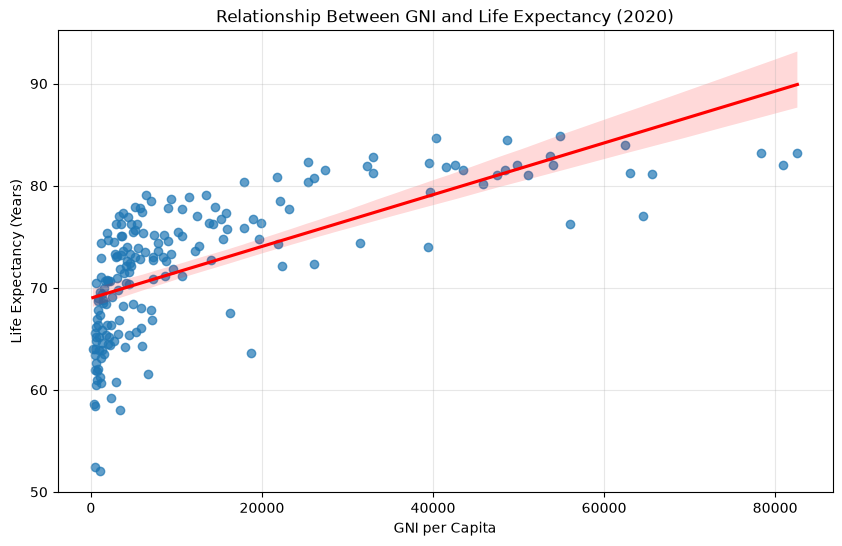

In [41]:
df_2020 = cleaned_pop_life_gni[cleaned_pop_life_gni["year"] == 2020]


plt.figure(figsize=(10, 6))

sns.regplot(
    data=df_2020,
    x="gni",
    y="life_exp",
    scatter_kws={"alpha":0.7},
    line_kws={"color":"red"}
)

plt.title("Relationship Between GNI and Life Expectancy (2020)")
plt.xlabel("GNI per Capita")
plt.ylabel("Life Expectancy (Years)")
plt.grid(alpha=0.3)
plt.show()

In [42]:
updated_summary[['gni_growth', 'pop_growth', 'life_exp_gain']].describe()

,gni_growth,pop_growth,life_exp_gain
count,190.000000,190.000000,190.000000
mean,3.830053,3.096053,15.787947
std,4.960800,7.426849,7.727380
min,-0.680000,-0.160000,-1.300000
25%,0.937500,0.680000,10.425000
50%,2.495000,2.125000,13.950000
75%,4.900000,3.507500,20.675000
max,33.620000,74.820000,49.900000


### 4.3. ----

In [53]:
hollow_growth = updated_summary[
    (updated_summary["gni_growth"] >= 4.90) &
    (updated_summary["pop_growth"] >= 3.5075) &
    (updated_summary["life_exp_gain"] <= 10)
]
hollow_growth

,country,year_start,year_end,population_start,population_end,life_exp_start,life_exp_end,gni_start,gni_end,pop_growth,life_exp_gain,gni_growth
21,Botswana,1960,2020,513000.0,2550000.0,54.4,61.6,432.0,6640.0,3.97,7.2,14.37


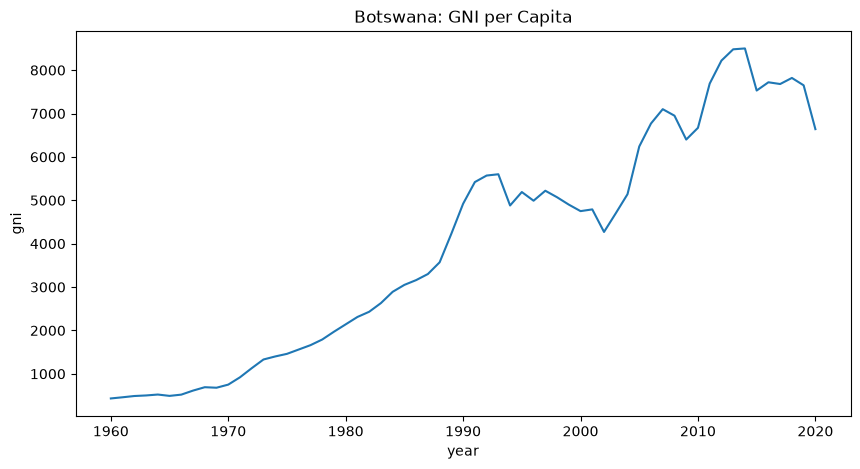

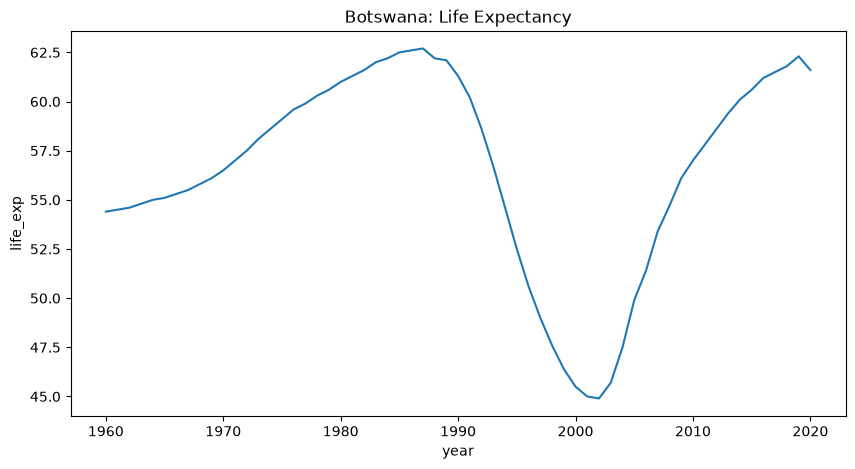

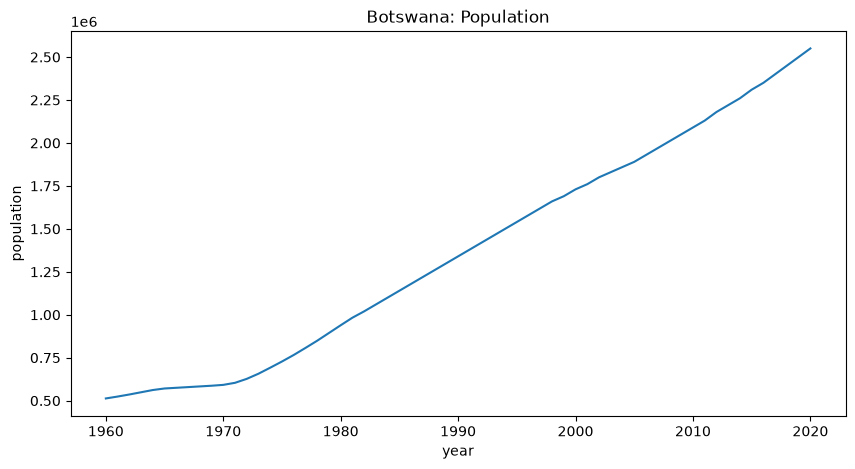

In [45]:
# Visualization 1 
for country in hollow_growth["country"]:

    country_data = cleaned_pop_life_gni[(cleaned_pop_life_gni["country"] == country) & (cleaned_pop_life_gni['year']>=1960) & (cleaned_pop_life_gni['year']<=2020)]

    plt.figure(figsize=(10,5))
    sns.lineplot(data=country_data, x="year", y="gni")
    plt.title(f"{country}: GNI per Capita")
    plt.show()

    plt.figure(figsize=(10,5))
    sns.lineplot(data=country_data, x="year", y="life_exp")
    plt.title(f"{country}: Life Expectancy")
    plt.show()

    plt.figure(figsize=(10,5))
    sns.lineplot(data=country_data, x="year", y="population")
    plt.title(f"{country}: Population")
    plt.show()

**Visualization 1 Interpretation:**
> *Write 2-3 sentences explaining exactly what relationship or pattern this chart demonstrates and how it addresses your project objectives.*

In [ ]:
# Visualization 2

**Visualization 2 Interpretation:**
> *Write 2-3 sentences explaining exactly what relationship or pattern this chart demonstrates and how it addresses your project objectives.*

---
## 5. Summary of Findings & Actionable Recommendations
*(Guidelines: Connect individual observations into a cohesive narrative that guides the target non-technical audience toward data-driven actions.)*

### 5.1 Key Insights (Summary of Findings)
*(Use bullet points to highlight the core truths revealed by your analysis)*
* ...
* ...

### 5.2 Actionable Recommendations
*(Translate your data into clear choices or recommendations for your stakeholder based directly on the problem statement)*
* ...
* ...

### 5.3 Limitations & Areas for Further Research
* ...

---

## 6. Data Dictionary & References

### 6.1 Data Dictionary
| Feature / Column | Data Type | Source | Description |
|:---|:---|:---|:---|
| column_name_1 | type | Original / Engineered | Detailed explanation of what this variable represents |
| column_name_2 | type | Original / Engineered | Detailed explanation of what this variable represents |

### 6.2 References & Sources
* *Source 1:*